In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Generate original sine wave
fs = 100
f0 = 2
t = np.arange(0, 2, 1 / fs)
x = np.sin(2 * np.pi * f0 * t)

In [ ]:
# Manual full convolution: y[n] = sum_k x[k] * h[n-k]
def manual_convolution_full(a, b):
    na = len(a)
    nb = len(b)
    y = np.zeros(na + nb - 1)
    for i in range(na):
        for j in range(nb):
            y[i + j] += (a[i] * b[j])
    return y

In [ ]:
# Manual delay by inserting leading zeros
delay_samples = 10
x_delayed = np.zeros(len(x))
for i in range(delay_samples, len(x)):
    x_delayed[i] = x[i - delay_samples]

# Cross-correlation manually using convolution with reversed signal
# corr_xy[l] = sum_n x_delayed[n] * x[n + l]
x_reversed = x[::-1]
corr = manual_convolution_full(x_delayed, x_reversed)
lags = np.arange(-len(x) + 1, len(x))

# Manual argmax to find delay at correlation peak
peak_index = 0
for i in range(1, len(corr)):
    if corr[i] > corr[peak_index]:
        peak_index = i
estimated_delay = lags[peak_index]

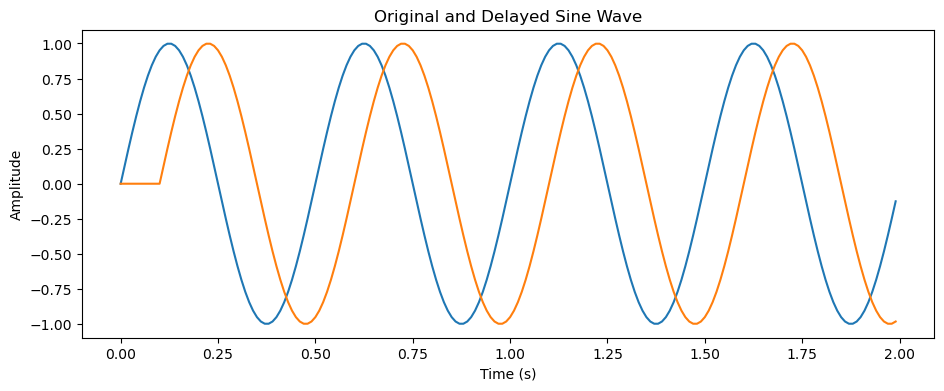

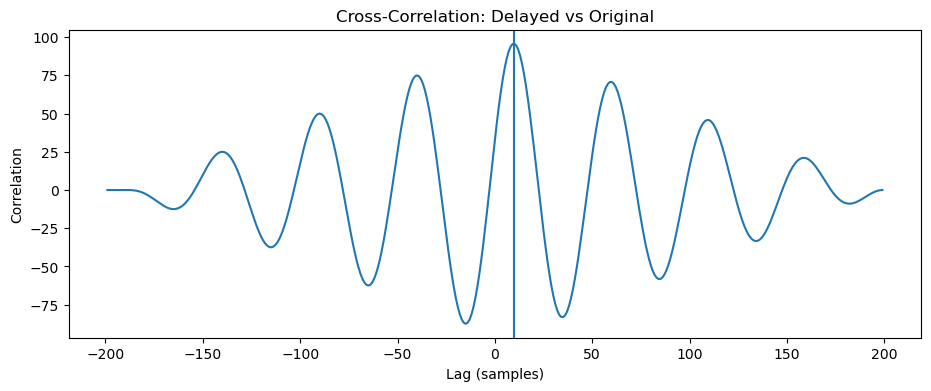

In [ ]:
# Plot signals
plt.figure(figsize=(15, 5))
plt.plot(t, x)
plt.plot(t, x_delayed)
plt.title('Original and Delayed Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Plot cross-correlation
plt.figure(figsize=(15, 5))
plt.plot(lags, corr)
plt.axvline(estimated_delay)
plt.title('Cross-Correlation: Delayed vs Original')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation')
plt.show()

In [4]:
print(f'Actual delay: {delay_samples} samples')
print(f'Estimated delay from correlation peak: {estimated_delay} samples')

Actual delay: 10 samples
Estimated delay from correlation peak: 10 samples
